###*This notebook uses edited survey data to predict both the population's poverty rate at various thresholds as well as household-level daily per capita consumption.*




In [3]:
import pandas as pd
import zipfile
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

import numpy as np

edited_train_set = pd.read_csv("edited_train_set.csv")

##Train set / Test set

In [4]:
#Target for regression
target_col = "cons_ppp17"

X = edited_train_set.drop(columns=[target_col])
y= edited_train_set[target_col]

X_cols = X.columns


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Scaling X | Prevent data leakage

scale = StandardScaler()

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

##Training ML Models

###Lasso Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.761e+06, tolerance: 8.400e+02
  model = cd_fast.enet_coordinate_descent(


Lasso MSE: 51.5489125758991
Lasso R2: 0.486924041766269
mean_num_children                         10.477302
num_adult_male                             5.952920
num_adult_female                           5.031555
num_elderly                                3.537069
utl_exp_ppp17                              2.625609
educ_max_Complete Tertiary Education       2.108840
dweltyp_Separate apartment                 1.393607
educ_max_Complete Secondary Education      1.078984
educ_max_Incomplete Tertiary Education     1.070416
region7                                    0.894609
dtype: float64


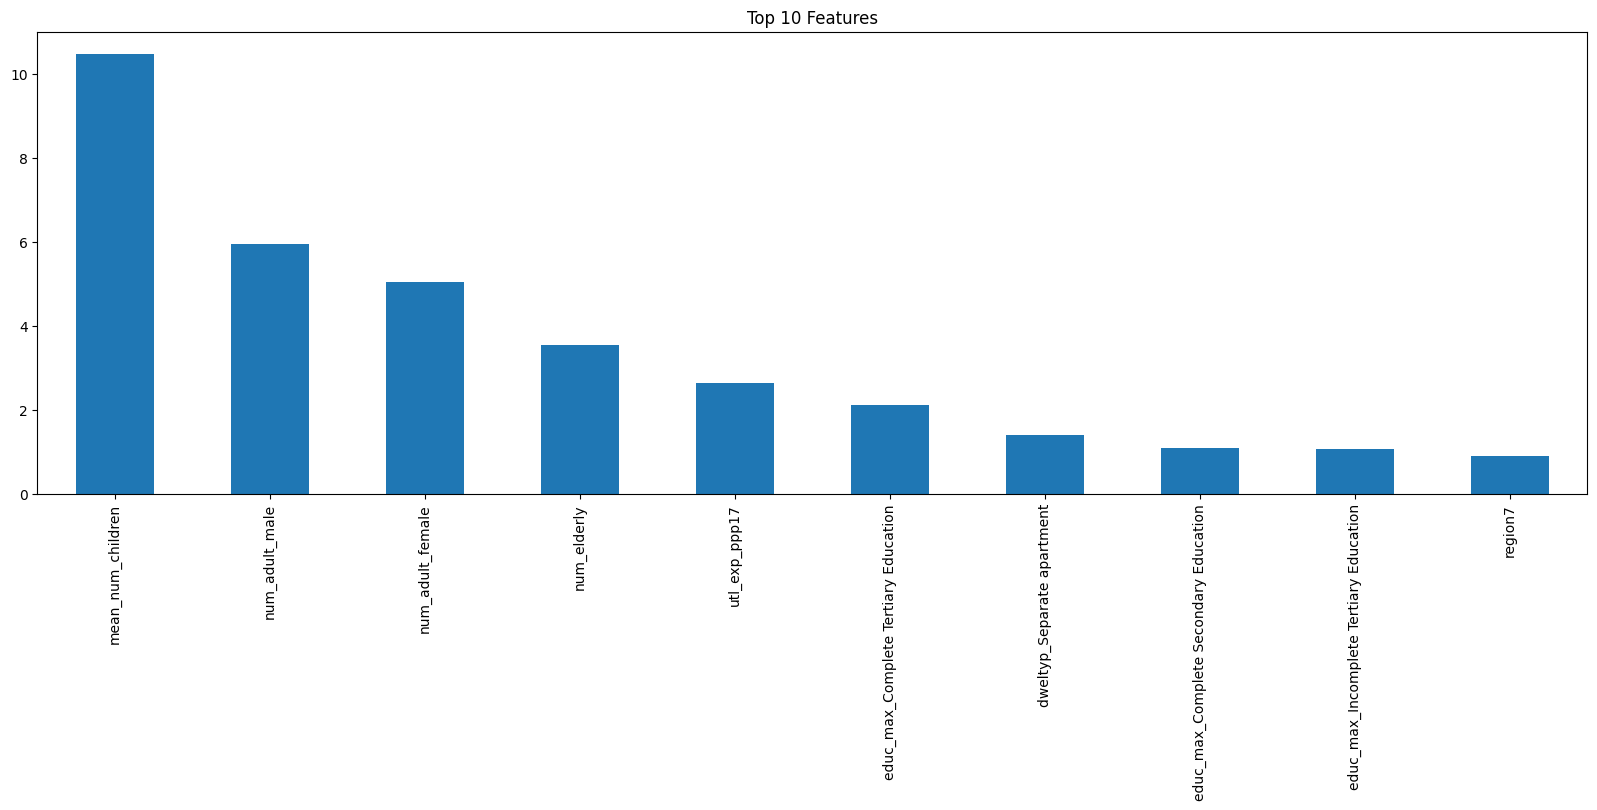

In [87]:
lasso = Lasso(alpha=0.001)

lasso.fit(X_train_scaled,y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test,y_pred_lasso)
print('Lasso MSE:', mse_lasso)
print('Lasso R2:',r2_score(y_test,y_pred_lasso))

#Coefficinecy of top 10 features with predictions
coefficient_lasso = pd.Series(lasso.coef_,index=X_cols).sort_values(ascending=False)
print(coefficient_lasso.head(10))

plt.figure(figsize=(20,6))
coefficient_lasso.head(10).plot(kind='bar',title='Top 10 Features')
plt.show()

###Gradient Boosting

Gradient Boosting MSE: 37.396617876721116
Gradient Boosting R2: 0.6277844751128643
hsize                                         0.213240
utl_exp_ppp17                                 0.182531
strata                                        0.157857
educ_max_Complete Tertiary Education          0.094431
sfworkershh                                   0.056445
dweltyp_Separate apartment                    0.050446
mean_num_children                             0.038578
weight                                        0.036508
Unnamed: 0                                    0.021457
sector1d_Agriculture, hunting and forestry    0.016777
dtype: float64


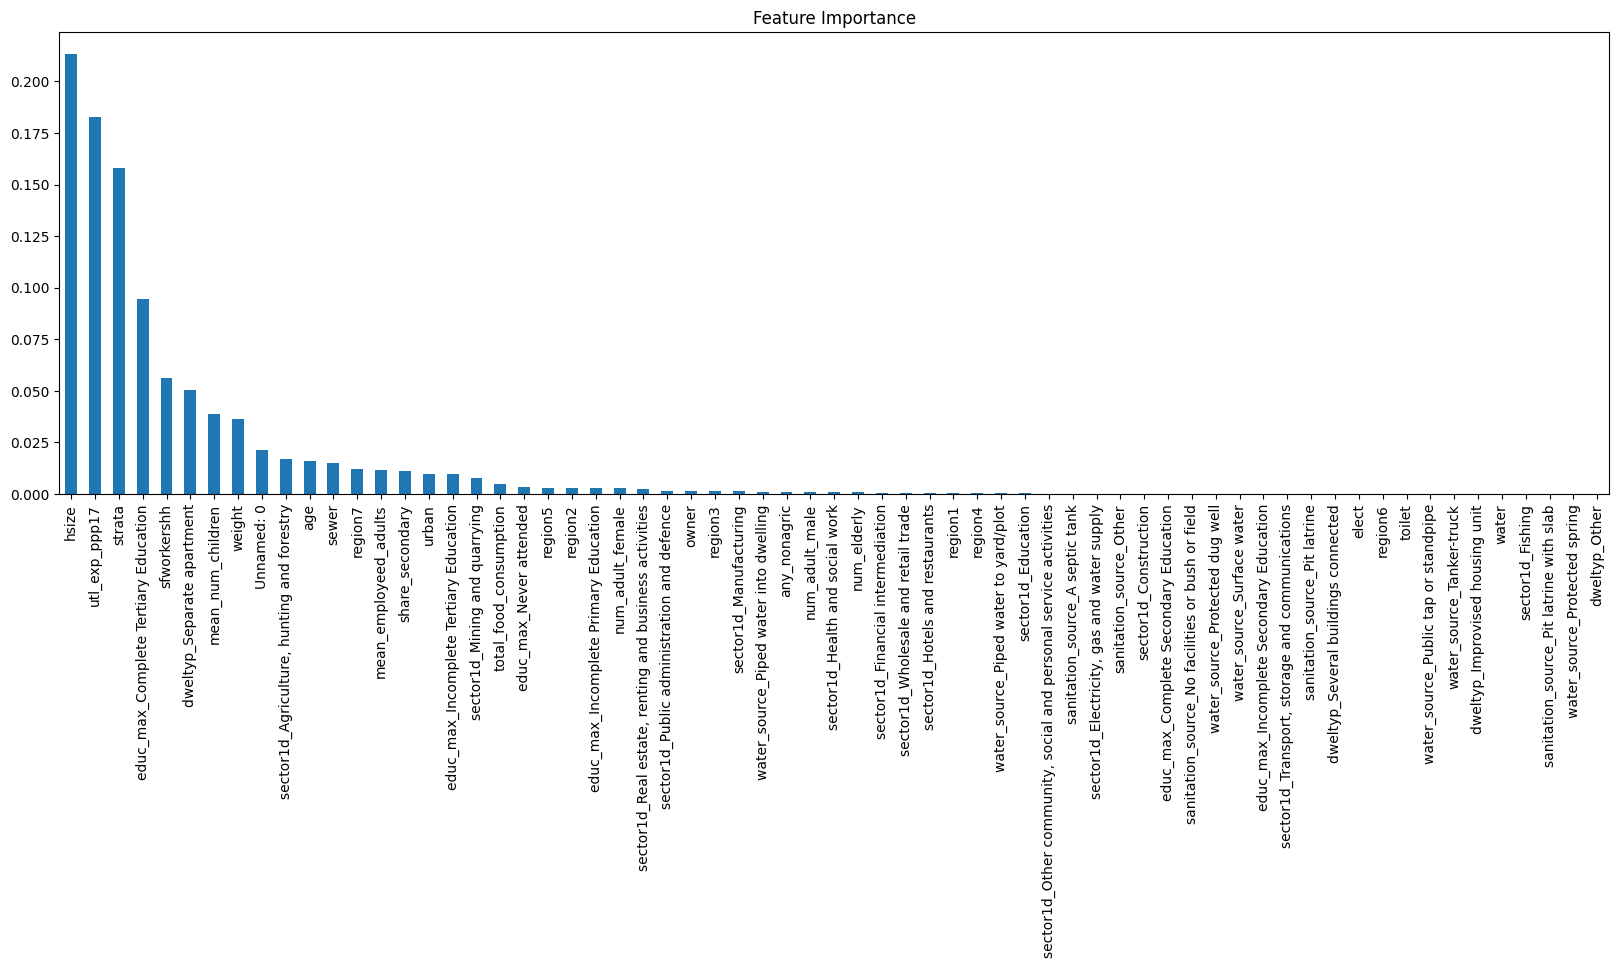

In [6]:

gb = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,random_state=42)

gb.fit(X_train_scaled,y_train)

y_pred_gb = gb.predict(X_test_scaled)

mse_gb = mean_squared_error(y_test,y_pred_gb)
print('Gradient Boosting MSE:', mse_gb)
print('Gradient Boosting R2:',r2_score(y_test,y_pred_gb))


#Feature importance top 10
feat_imp = pd.Series(gb.feature_importances_,index=X_cols).sort_values(ascending=False)
print(feat_imp.head(10))

plt.figure(figsize=(20,6))
feat_imp.plot(kind='bar',title='Feature Importance')
plt.show()

###SVR

In [ ]:
#SVR

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

svr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", gamma=0.1, epsilon=0.1))
])



svr.fit(X_train_scaled,y_train)

y_pred_svr = svr.predict(X_test_scaled)

mse_svr = mean_squared_error(y_test,y_pred_svr)
print('SVR MSE:', mse_svr)
print('SVR R2:',r2_score(y_test,y_pred_svr))

SVR MSE: 62.956188862023296
SVR R2: 0.37338528956228034


###Deep Learning - MLP



MSE MLP: 38.85385890067671
MSE R2: 0.6132802829314546
hsize                                     0.262048
utl_exp_ppp17                             0.223034
educ_max_Complete Tertiary Education      0.079199
mean_num_children                         0.056388
sfworkershh                               0.041634
dweltyp_Separate apartment                0.026674
num_adult_female                          0.025806
educ_max_Incomplete Tertiary Education    0.024022
num_elderly                               0.018502
strata                                    0.018383
dtype: float64


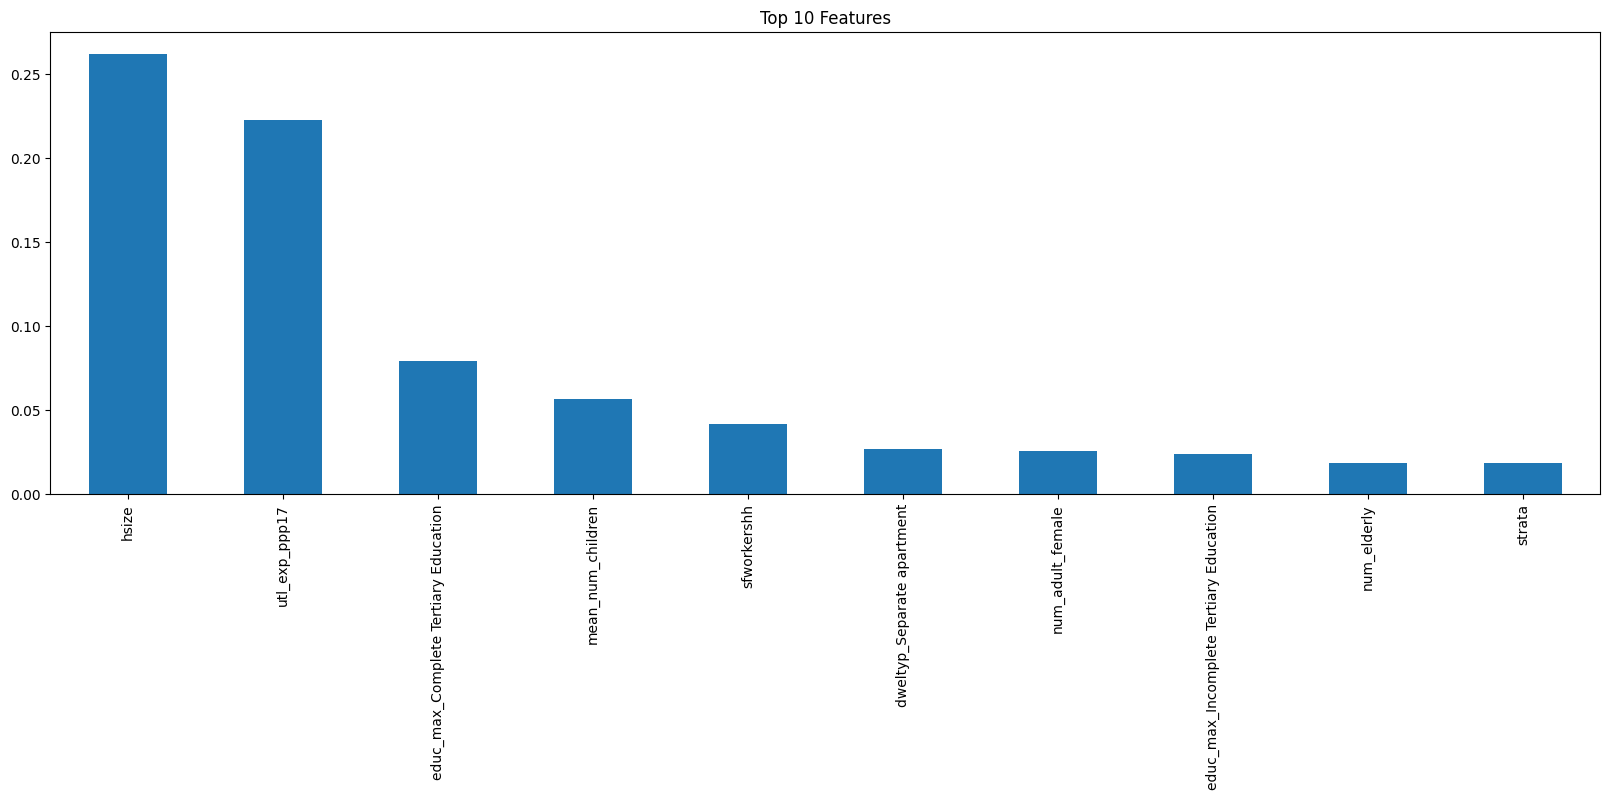

In [4]:
mlp = MLPRegressor(hidden_layer_sizes=(128,64),activation='relu',solver='adam',random_state=42,max_iter=1000,early_stopping=True,validation_fraction=0.1)

mlp.fit(X_train_scaled,y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

mse_mlp = mean_squared_error(y_test,y_pred_mlp)
print('MSE MLP:',mse_mlp)
print('MSE R2:',r2_score(y_test,y_pred_mlp))

result = permutation_importance(mlp,X_test_scaled,y_test,n_repeats=10,random_state=42)
feature_importances_mlp = pd.Series(result.importances_mean,index=X_cols).sort_values(ascending=False)
print(feature_importances_mlp.head(10))

plt.figure(figsize=(20,6))
feature_importances_mlp.head(10).plot(kind='bar',title='Top 10 Features')
plt.show()


#Export results

##Test on test set


In [ ]:
test_set = pd.read_csv("test_hh_features.csv")

with open("drop_cols.txt") as f:
  drop_cols = [line.strip() for line in f]

test_set = test_set.drop(columns=drop_cols)

total_consumtion = []
for col in test_set.columns:
  if col.startswith("consumed"):
    total_consumtion.append(col)

test_set[total_consumtion] = test_set[total_consumtion].apply(
pd.to_numeric, errors="coerce"
).fillna(0)

test_set["total_food_consumption"] = test_set[total_consumtion].sum(axis=1)
test_set = test_set.drop(columns=total_consumtion)

children = []
for col in test_set.columns:
  if col.startswith("num_children"):
    children.append(col)

test_set[children] = test_set[children].apply(
pd.to_numeric, errors="coerce"
).fillna(0)

test_set["mean_num_children"] = test_set[children].sum(axis=1)
test_set = test_set.drop(columns=children)

employeed_adults = []
keywords = ["employed","sworkershh"]
for col in test_set.columns:
  if any(k in col for k in keywords):
    employeed_adults.append(col)

test_set[employeed_adults] = test_set[employeed_adults].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)


test_set["mean_employeed_adults"] = test_set[employeed_adults].sum(axis=1)
test_set = test_set.drop(columns=employeed_adults)

binary_cols = ['owner', 'water', 'toilet', 'sewer', 'elect', 'any_nonagric', 'urban']

for col in binary_cols:
    test_set[col] = (
        test_set[col]
        .astype(str)
        .str.lower()
        .map({
            'yes': 1, 'no': 0,
            'owner': 1, 'not owner': 0,
            'urban': 1, 'rural': 0
        })
        .fillna(0)
        .astype(int)
    )

test_set = test_set.reindex(columns=X_cols, fill_value=0)


In [ ]:
assert list(test_set.columns) == list(X_cols)
test_set.select_dtypes(include="object").columns


In [ ]:
#Check for features with NaN values
test_set.isna().sum().sort_values(ascending=False).head(20)

#Remove remaining NaN values from test set numerical columns
num_cols = test_set.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
  test_set[col] = test_set[col].fillna(test_set[col].median())

#Remove remaining NaN values from test set categorical columns
cat_cols = test_set.select_dtypes(include=["object","category"]).columns
for col in cat_cols:
  test_set[col] = test_set[col].fillna(test_set[col].mode()[0])

In [ ]:
#Check for remaining NaN values
print(test_set.isna().sum().sum())

In [ ]:
y_pred_test = gb.predict(test_set)

In [ ]:
#Check validity of test predictions to train set
print("Test set")
print(y_pred_test.min(), y_pred_test.mean(), y_pred_test.max())
print("Train set")
print(y_train.min(), y_train.mean(), y_train.max())

##Predicted_household_consumption.csv

In [ ]:
#Create file
test_ids = pd.read_csv("test_hh_features.csv")[["survey_id","hhid"]]
pred_consumption = pd.DataFrame({"survey_id":test_ids["survey_id"],"household_id":test_ids["hhid"],"cons_ppp17":y_pred_test})

In [ ]:
#Export file
pred_consumption.to_csv("predicted_household_consumption.csv",index=False)

##Predicted poverty distribution

In [ ]:
#Load poverty rates
train_povrate_labels = pd.read_csv("train_rates_gt.csv")

#Create a new dataframe for test set
test_set = pd.read_csv("test_hh_features.csv")
poverty_df = test_set[["survey_id"]].copy()
poverty_df["prediction_cons"] = y_pred_test

In [ ]:
thresholds = [float(col.replace("pct_hh_below_", "")) for col in train_povrate_labels.columns if col.startswith("pct_hh_below_")]
print(thresholds)

In [ ]:
poverty_distribution = []

for survey_id, group in poverty_df.groupby("survey_id"):
  row = {"survey_id": survey_id}
  for thr in thresholds:
    row[f"pct_hh_below_{thr:.2f}"] = (group["prediction_cons"] < thr).mean()
  poverty_distribution.append(row)

pred_poverty = pd.DataFrame(poverty_distribution)

In [ ]:
#Export file
pred_poverty.to_csv("predicted_poverty_distribution.csv",index=False)

###Export zip

In [ ]:
with zipfile.ZipFile("submission.zip", "w") as z:
   z.write("predicted_household_consumption.csv")
   z.write("predicted_poverty_distribution.csv")

